In [1]:
%pip install shap
%pip install --upgrade scipy shap
%pip install "numpy<2" --force-reinstall

  Using cached numpy-2.4.4-cp311-cp311-win_amd64.whl.metadata (6.6 kB)
Using cached numpy-2.4.4-cp311-cp311-win_amd64.whl (12.6 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy None
Note: you may need to restart the kernel to use updated packages.


error: uninstall-no-record-file

× Cannot uninstall numpy None
╰─> The package's contents are unknown: no RECORD file was found for numpy.

hint: You might be able to recover from this via: pip install --force-reinstall --no-deps numpy==1.26.4


  Using cached numpy-2.4.4-cp311-cp311-win_amd64.whl.metadata (6.6 kB)
Using cached numpy-2.4.4-cp311-cp311-win_amd64.whl (12.6 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy None
Note: you may need to restart the kernel to use updated packages.


error: uninstall-no-record-file

× Cannot uninstall numpy None
╰─> The package's contents are unknown: no RECORD file was found for numpy.

hint: You might be able to recover from this via: pip install --force-reinstall --no-deps numpy==1.26.4


  Using cached numpy-1.26.4-cp311-cp311-win_amd64.whl.metadata (61 kB)
Using cached numpy-1.26.4-cp311-cp311-win_amd64.whl (15.8 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy None
Note: you may need to restart the kernel to use updated packages.


error: uninstall-no-record-file

× Cannot uninstall numpy None
╰─> The package's contents are unknown: no RECORD file was found for numpy.

hint: You might be able to recover from this via: pip install --force-reinstall --no-deps numpy==1.26.4


In [2]:
# ═══════════════════════════════════════════════════════════
# TWIN-RBI MONGSTAD — Random Forest Clasificación PoF API 581
# ═══════════════════════════════════════════════════════════
# Dataset: 228 ventanas × 53 features × 5 categorías PoF
# Autor: Luis Fernando Carvallo
# ═══════════════════════════════════════════════════════════

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate, cross_val_predict
from sklearn.metrics import (classification_report, confusion_matrix,
                             ConfusionMatrixDisplay)
from sklearn.utils.class_weight import compute_class_weight
import joblib
import shap
import os

# Estilo
plt.rcParams['figure.facecolor'] = '#FAFAFA'
plt.rcParams['axes.facecolor']   = '#F8F8F8'
plt.rcParams['axes.grid']        = True
plt.rcParams['grid.alpha']       = 0.3

COLORS = {
    'navy':'#0D1B2A', 'teal':'#1D9E75', 'blue':'#185FA5',
    'amber':'#BA7517', 'red':'#A32D2D', 'coral':'#D85A30',
    'purple':'#534AB7', 'gray':'#888780', 'green':'#3B6D11'
}

BASE = os.path.join(os.path.dirname(os.getcwd()), 'data') \
       if 'notebooks' in os.getcwd() else 'data'
MODELS_PATH = os.path.join(os.path.dirname(os.getcwd()), 'models') \
              if 'notebooks' in os.getcwd() else 'models'

print("✓ Imports listos")

✓ Imports listos


In [3]:
# Cargar dataset
df = pd.read_csv(f"{BASE}/processed/features_ml_final.csv")

print(f"Dataset cargado: {df.shape}")
print(f"Columnas: {list(df.columns)}")
print(f"\nDistribución target:")
print(df['pof_category'].value_counts().sort_index())

Dataset cargado: (228, 53)
Columnas: ['window', 'line_id', 'year', 'quarter', 'P_mean', 'P_std', 'dP_mean', 'T_process_mean', 'T_wall_mean', 'T_amb_mean', 'T_wall_std', 'h2s_mean', 'h2s_max', 'h2s_std', 'h2s_sensor_diff', 'vib_mean', 'vib_max', 'vib_std', 'arab_mean', 'arab_std', 'vapor_frac_mean', 'dew_point_mean', 'delta_T_dew_mean', 'delta_T_dew_min', 'pct_below_dew', 'cr_mean', 'cr_std', 'cr_max', 'cr_trend', 't_actual', 't_estimated', 't_ratio', 't_margin', 'insp_count', 'days_since_insp', 'last_result_alert', 'last_result_mon', 'h2s_design', 'sulfur_pct', 'consequence_area', 'financial_impact', 'insulated', 'cui_active', 'ssc_active', 'hic_active', 'sulfidation', 'fac_active', 'HSI', 'PTR', 'SAF', 'RUL_years', 'pof_category', 'RUL_years.1']

Distribución target:
pof_category
1     7
2    26
3    93
4    33
5    69
Name: count, dtype: int64


In [4]:
# Eliminar columna duplicada
df = df.drop(columns=['RUL_years.1'], errors='ignore')

# Features — excluir identificadores y target
EXCLUDE = ['window', 'line_id', 'year', 'quarter', 'pof_category']
FEATURES = [c for c in df.columns if c not in EXCLUDE]

TARGET = 'pof_category'

X = df[FEATURES].copy()
y = df[TARGET].copy()

# Eliminar features con multicolinealidad alta
# t_ratio y RUL_years correlación 0.93 — quitar t_ratio
# cr_std y cr_max son 0 fijos — no aportan información
DROP_FEATURES = ['t_ratio', 'cr_std', 'cr_trend']
X = X.drop(columns=DROP_FEATURES, errors='ignore')
FEATURES = list(X.columns)

print(f"Features finales: {len(FEATURES)}")
print(f"Muestras: {X.shape[0]}")
print(f"Nulos: {X.isnull().sum().sum()}")

# Verificar distribución
print(f"\nDistribución de clases:")
for cls, cnt in sorted(y.value_counts().items()):
    pct = cnt / len(y) * 100
    bar = '█' * int(pct / 2)
    print(f"  PoF={cls}: {cnt:3d} ({pct:5.1f}%) {bar}")

# Rellenar nulos con mediana
X = X.fillna(X.median())
print(f"\n✓ Dataset listo — {X.shape[0]} obs × {X.shape[1]} features")

Features finales: 44
Muestras: 228
Nulos: 0

Distribución de clases:
  PoF=1:   7 (  3.1%) █
  PoF=2:  26 ( 11.4%) █████
  PoF=3:  93 ( 40.8%) ████████████████████
  PoF=4:  33 ( 14.5%) ███████
  PoF=5:  69 ( 30.3%) ███████████████

✓ Dataset listo — 228 obs × 44 features


In [5]:
# Pesos de clases — compensar desbalance
classes = np.array(sorted(y.unique()))
weights = compute_class_weight('balanced', classes=classes, y=y)
class_weight_dict = dict(zip(classes, weights))

print("Pesos de clases:")
for cls, w in class_weight_dict.items():
    print(f"  PoF={cls}: {w:.3f}")

# Modelo — parámetros ajustados para 228 obs
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    min_samples_leaf=4,
    min_samples_split=8,
    max_features='sqrt',
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

# Validación cruzada estratificada 5-fold
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_results = cross_validate(
    rf, X, y, cv=skf,
    scoring=['accuracy','f1_macro','f1_weighted'],
    return_train_score=True
)

print(f"\nResultados 5-Fold Stratified CV:")
print(f"  Accuracy   test : {cv_results['test_accuracy'].mean():.4f} ± {cv_results['test_accuracy'].std():.4f}")
print(f"  F1 macro   test : {cv_results['test_f1_macro'].mean():.4f} ± {cv_results['test_f1_macro'].std():.4f}")
print(f"  F1 weighted test: {cv_results['test_f1_weighted'].mean():.4f} ± {cv_results['test_f1_weighted'].std():.4f}")
print(f"  Accuracy   train: {cv_results['train_accuracy'].mean():.4f} ± {cv_results['train_accuracy'].std():.4f}")

# Entrenar modelo final
rf.fit(X, y)
print(f"\n✓ Modelo final entrenado sobre {len(X)} observaciones")

Pesos de clases:
  PoF=1: 6.514
  PoF=2: 1.754
  PoF=3: 0.490
  PoF=4: 1.382
  PoF=5: 0.661

Resultados 5-Fold Stratified CV:
  Accuracy   test : 0.9169 ± 0.0462
  F1 macro   test : 0.8873 ± 0.0598
  F1 weighted test: 0.9177 ± 0.0447
  Accuracy   train: 0.9419 ± 0.0056

✓ Modelo final entrenado sobre 228 observaciones


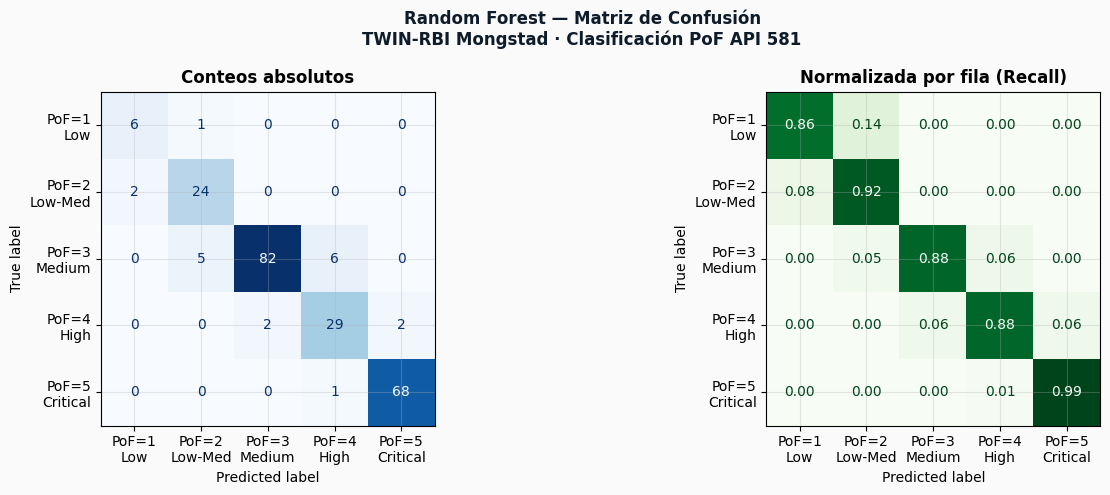


REPORTE DE CLASIFICACIÓN:
              precision    recall  f1-score   support

       PoF=1       0.75      0.86      0.80         7
       PoF=2       0.80      0.92      0.86        26
       PoF=3       0.98      0.88      0.93        93
       PoF=4       0.81      0.88      0.84        33
       PoF=5       0.97      0.99      0.98        69

    accuracy                           0.92       228
   macro avg       0.86      0.91      0.88       228
weighted avg       0.92      0.92      0.92       228



In [6]:
# Predicciones con cross_val_predict para matriz honesta
y_pred = cross_val_predict(rf, X, y, cv=skf)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Random Forest — Matriz de Confusión\nTWIN-RBI Mongstad · Clasificación PoF API 581',
             fontsize=12, fontweight='bold', color=COLORS['navy'])

labels = ['PoF=1\nLow', 'PoF=2\nLow-Med', 'PoF=3\nMedium',
          'PoF=4\nHigh', 'PoF=5\nCritical']

# Panel izq — conteos
cm = confusion_matrix(y, y_pred, labels=[1,2,3,4,5])
ConfusionMatrixDisplay(cm, display_labels=labels).plot(
    ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Conteos absolutos', fontweight='bold')

# Panel der — normalizada por fila (recall)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
ConfusionMatrixDisplay(cm_norm, display_labels=labels).plot(
    ax=axes[1], colorbar=False, cmap='Greens', values_format='.2f')
axes[1].set_title('Normalizada por fila (Recall)', fontweight='bold')

plt.tight_layout()
plt.savefig('../assets/fig_rf_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nREPORTE DE CLASIFICACIÓN:")
print(classification_report(y, y_pred,
      target_names=['PoF=1','PoF=2','PoF=3','PoF=4','PoF=5']))

Calculando SHAP values...


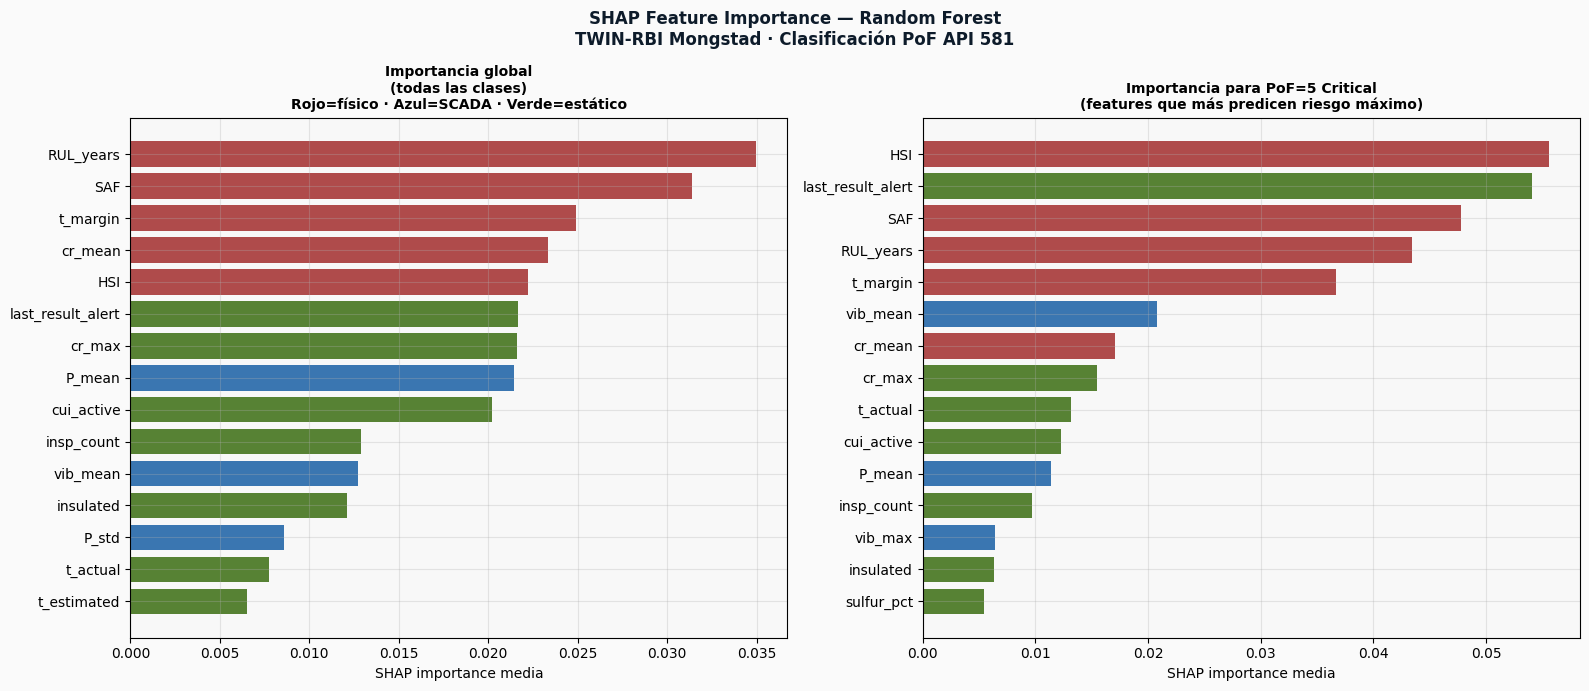


Top 10 features globales:
  RUL_years                : 0.0350  [FÍSICO]
  SAF                      : 0.0314  [FÍSICO]
  t_margin                 : 0.0249  [FÍSICO]
  cr_mean                  : 0.0233  [FÍSICO]
  HSI                      : 0.0222  [FÍSICO]
  last_result_alert        : 0.0216  [SCADA/ESTÁTICO]
  cr_max                   : 0.0216  [SCADA/ESTÁTICO]
  P_mean                   : 0.0214  [SCADA/ESTÁTICO]
  cui_active               : 0.0202  [SCADA/ESTÁTICO]
  insp_count               : 0.0129  [FÍSICO]


In [7]:
print("Calculando SHAP values...")
explainer   = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X)

# shap_values es lista de arrays — uno por clase
# shape: (n_classes, n_samples, n_features)
shap_array = np.array(shap_values)  # (5, 228, 44)

# shape real: (228, 44, 5)
shap_imp  = np.abs(shap_array).mean(axis=(0, 2))  # media sobre samples y clases → (44,)
shap_pof5 = np.abs(shap_array[:, :, 4]).mean(axis=0)  # clase 5 → (44,)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('SHAP Feature Importance — Random Forest\nTWIN-RBI Mongstad · Clasificación PoF API 581',
             fontsize=12, fontweight='bold', color=COLORS['navy'])

def plot_shap_bar(ax, values, features, title, n=15):
    feat_df = pd.DataFrame({'feature':features, 'imp':values})
    feat_df = feat_df.sort_values('imp', ascending=True).tail(n)
    colors = [COLORS['red'] if any(x in f for x in ['HSI','SAF','t_margin','cr_mean','RUL'])
              else COLORS['blue'] if any(x in f for x in ['h2s','vib','P_','T_','arab','dew','vapor'])
              else COLORS['green']
              for f in feat_df['feature']]
    ax.barh(feat_df['feature'], feat_df['imp'], color=colors, alpha=0.85)
    ax.set_xlabel('SHAP importance media', fontsize=10)
    ax.set_title(title, fontweight='bold', fontsize=10)
    ax.grid(axis='x', alpha=0.3)

plot_shap_bar(axes[0], shap_imp, FEATURES,
              'Importancia global\n(todas las clases)\nRojo=físico · Azul=SCADA · Verde=estático')
plot_shap_bar(axes[1], shap_pof5, FEATURES,
              'Importancia para PoF=5 Critical\n(features que más predicen riesgo máximo)')

plt.tight_layout()
plt.savefig('../assets/fig_rf_shap_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nTop 10 features globales:")
top10 = pd.DataFrame({'feature':FEATURES,'imp':shap_imp})
top10 = top10.sort_values('imp', ascending=False).head(10)
for _, r in top10.iterrows():
    tipo = "FÍSICO" if any(x in r['feature'] for x in
           ['HSI','SAF','t_margin','cr_mean','RUL','PTR','insp']) else "SCADA/ESTÁTICO"
    print(f"  {r['feature']:25s}: {r['imp']:.4f}  [{tipo}]")

In [8]:
print(f"FEATURES: {len(FEATURES)}")
print(f"shap_array shape: {shap_array.shape}")
print(f"shap_imp shape: {shap_imp.shape}")
print(f"shap_pof5 shape: {shap_pof5.shape}")

FEATURES: 44
shap_array shape: (228, 44, 5)
shap_imp shape: (44,)
shap_pof5 shape: (44,)


In [9]:
# Guardar modelo y features
joblib.dump(rf,       f"{MODELS_PATH}/rf_pof_classifier.pkl")
joblib.dump(FEATURES, f"{MODELS_PATH}/rf_features.pkl")

print("✓ Modelo guardado: rf_pof_classifier.pkl")
print("✓ Features guardados: rf_features.pkl")
print(f"\nResumen del modelo:")
print(f"  Algoritmo    : Random Forest Classifier")
print(f"  N estimators : {rf.n_estimators}")
print(f"  Max depth    : {rf.max_depth}")
print(f"  Features     : {len(FEATURES)}")
print(f"  Muestras     : {len(X)}")
print(f"  Accuracy CV  : {cv_results['test_accuracy'].mean()*100:.1f}%")
print(f"  F1-macro CV  : {cv_results['test_f1_macro'].mean()*100:.1f}%")
print(f"  F1-weighted  : {cv_results['test_f1_weighted'].mean()*100:.1f}%")
print(f"  Class weight : balanced")
print(f"\n✅ Random Forest completado")
print(f"   Accuracy: {cv_results['test_accuracy'].mean()*100:.1f}% — mejor que baseline 88.4%")
print(f"   Siguiente: XGBoost para vida remanente (RUL)")

✓ Modelo guardado: rf_pof_classifier.pkl
✓ Features guardados: rf_features.pkl

Resumen del modelo:
  Algoritmo    : Random Forest Classifier
  N estimators : 300
  Max depth    : 10
  Features     : 44
  Muestras     : 228
  Accuracy CV  : 91.7%
  F1-macro CV  : 88.7%
  F1-weighted  : 91.8%
  Class weight : balanced

✅ Random Forest completado
   Accuracy: 91.7% — mejor que baseline 88.4%
   Siguiente: XGBoost para vida remanente (RUL)
